In [1]:
# Import the necessary libraries
import pandas as pd
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [108]:
# Import Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the datasets from the CSV files
dynamically_generated_hate_speech_dataset = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_cleaned_words.csv")
convabuse = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/convabuse_cleaned_words.csv")
online_abusive_attacks = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_cleaned_words.csv")
us_elections_2020_hate_speech = pd.read_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_cleaned_words.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# U.S. Elections 2020 Hate Speech

In [6]:
# Get the head of each dataset
us_elections_2020_hate_speech.head()

,text,Trump,Biden,West,HOF
0,@SukiRavan @ProgressPotato @MarkZuckerb0rg @JS...,0.0,4.0,0.0,Non-Hateful
1,@Newsweek Are you freaking crazy????[NEWLINE]I...,0.0,4.0,0.0,Non-Hateful
2,Undecided voters (and MAGATs alike);[NEWLINE]I...,1.0,2.0,0.0,Non-Hateful
3,@cheaterwins @Hungry_For_More @DAYSORSHAY So a...,4.0,2.0,0.0,Non-Hateful
4,@CNN Nancy Pelosi and the Dems wont do a deal ...,2.0,0.0,0.0,Non-Hateful


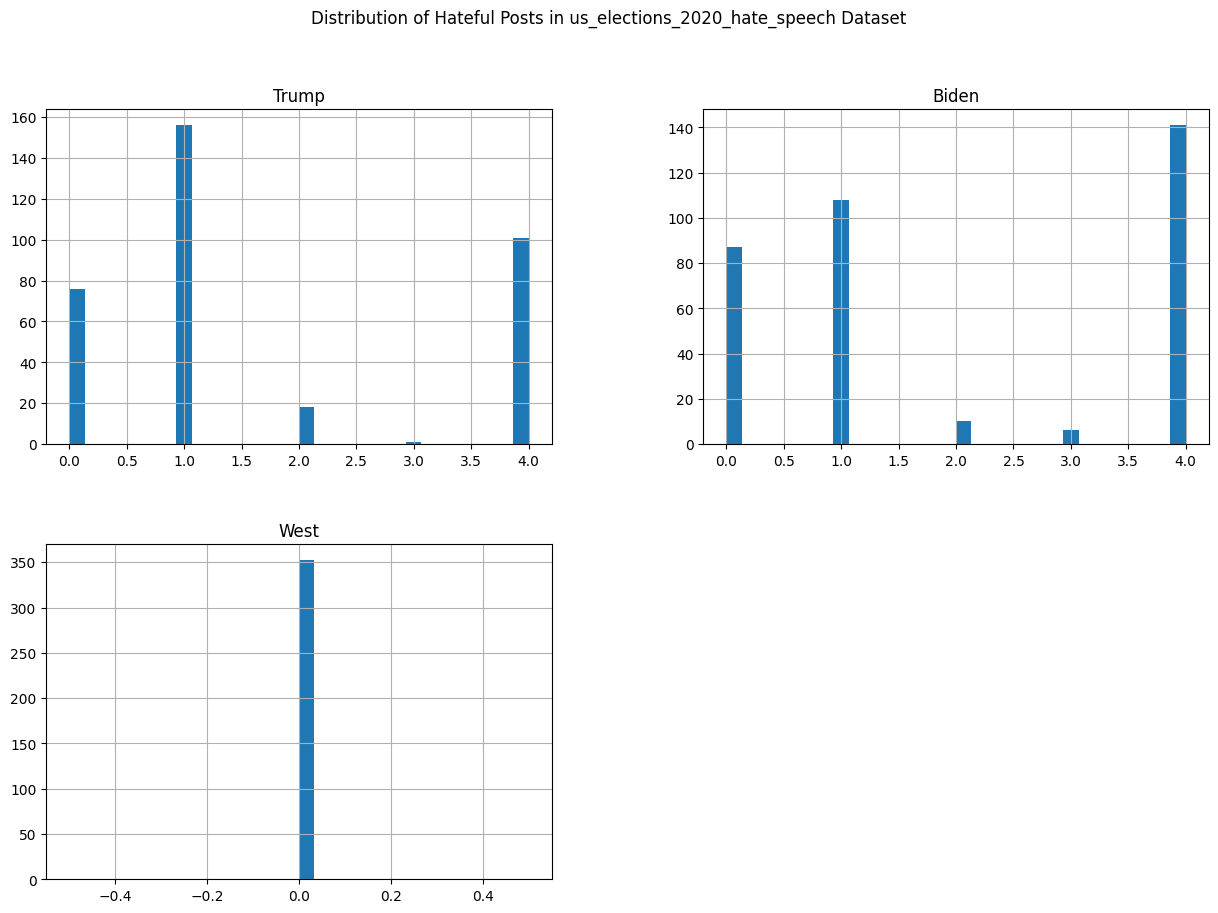

In [7]:
# Group by HOF
hate_results = us_elections_2020_hate_speech[us_elections_2020_hate_speech['HOF'] == 'Hateful']

# Get a distribution plot of hateful posts in the us_elections_2020_hate_speech dataset
hate_results.hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribution of Hateful Posts in us_elections_2020_hate_speech Dataset")
plt.show()

In [8]:
us_elections_2020_hate_speech[us_elections_2020_hate_speech['West'] != 0]

,text,Trump,Biden,West,HOF
462,"Non Of Us Are Our Ancestors, Let's Make Sure W...",0.0,0.0,3.0,Non-Hateful
521,Kanye west campaign ad 🇺🇸[NEWLINE]Unofficial f...,0.0,0.0,2.0,Non-Hateful
1667,"@Hoosiers1986 The media, which includes Hollyw...",4.0,0.0,3.0,Non-Hateful
2059,Everyday I wake up thinking Kanye suck on thes...,0.0,0.0,1.0,Non-Hateful
2226,@montaga @instagram @Facebook @tedcruz @Michel...,0.0,0.0,2.0,Non-Hateful
2293,KANYE WON FOUR BILLBOARD AWARDS LESSSSGOOOOOOO...,0.0,0.0,3.0,Non-Hateful
2433,"“When I talk, it’s not a rant, it’s a symphony...",0.0,0.0,2.0,Non-Hateful
2558,@MsResistFL @PeterDaszak You’re right! [NEWLIN...,1.0,4.0,1.0,Non-Hateful
2993,@realDonaldTrump Cause You Mr President @realD...,1.0,0.0,3.0,Non-Hateful


In [9]:
# Output the dataframe as a CSV file
us_elections_2020_hate_speech.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_cleaned1_words.csv", index=False)

# Dynamically Generated Hate Speech Dataset

In [10]:
dynamically_generated_hate_speech_dataset.head()

,label,text,type,target,level,annotator
0,hate,dalits are lowlives,unclear,notgiven,original,3
1,hate,gay people are a burden to our society,unclear,notgiven,original,3
2,hate,Arabs are not welcome,unclear,notgiven,original,18
3,hate,I'm not saying we should actually eliminate he...,unclear,notgiven,original,16
4,hate,bananas are for black people,unclear,notgiven,original,7


In [11]:
# Get the unique values of the type column
dynamically_generated_hate_speech_dataset["type"].unique()

array(['unclear', 'none', 'derogation', 'animosity', 'dehumanization',
       'threatening', 'support'], dtype=object)

In [12]:
# Get the unique values of the "label" feature
dynamically_generated_hate_speech_dataset["label"].unique()

array(['hate', 'nothate'], dtype=object)

In [13]:
# Change the hate speech labels to binary values
dynamically_generated_hate_speech_dataset["label"] = dynamically_generated_hate_speech_dataset["label"].replace({"hate": 1, "nothate": 0})

/tmp/ipython-input-4208641788.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dynamically_generated_hate_speech_dataset["label"] = dynamically_generated_hate_speech_dataset["label"].replace({"hate": 1, "nothate": 0})


In [14]:
# Get the unique values of the "label" column
dynamically_generated_hate_speech_dataset["label"].unique()

array([1, 0])

In [15]:
# Convert the "label" feature to integer type
dynamically_generated_hate_speech_dataset["label"] = dynamically_generated_hate_speech_dataset["label"].astype(np.number)

/usr/local/lib/python3.12/dist-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)


In [16]:
# Get the unique values of the type column in the dynamically_generated_hate_speech_dataset
dynamically_generated_hate_speech_dataset["type"].unique()

array(['unclear', 'none', 'derogation', 'animosity', 'dehumanization',
       'threatening', 'support'], dtype=object)

In [17]:
# Replace "unclear" and "none" with 0, "derogation", "dehumanization", "animosity", and "threatening" with -1, and "support" with 1 in the "type" column
dynamically_generated_hate_speech_dataset["type"] = dynamically_generated_hate_speech_dataset["type"].replace({
    "unclear": 0,
    "none": 0,
    "derogation": -1,
    "dehumanization": -1,
    "animosity": -1,
    "threatening": -1,
    "support": 1
})

/tmp/ipython-input-4162786069.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dynamically_generated_hate_speech_dataset["type"] = dynamically_generated_hate_speech_dataset["type"].replace({


In [18]:
# Get the unique values of the level column in the dynamically_generated_hate_speech_dataset
dynamically_generated_hate_speech_dataset["level"].unique()

array(['original', 'perturbation'], dtype=object)

In [19]:
# Get the count of original data in the "level" column
dynamically_generated_hate_speech_dataset["level"].value_counts()

,count
level,
original,26095
perturbation,15049


In [20]:
dynamically_generated_hate_speech_dataset["target"].value_counts()

,count
target,
none,18969
notgiven,7110
wom,2035
bla,1961
jew,1096
...,...
"trans, lgbtq",1
"asi, non.white, african",1
"mus, bla, immig, non.white",1


In [21]:
# Convert the target column to a string type
dynamically_generated_hate_speech_dataset["target"] = dynamically_generated_hate_speech_dataset["target"].astype(str)

In [22]:
# Get all values with a comma in the target column and call them unique_targets
unique_targets = [id for id in dynamically_generated_hate_speech_dataset["target"] if "," in id]
unique_targets

['dis, gay',
 'mus, arab, other.religion',
 'mus, jew',
 'bla, asi',
 'bla, gay',
 'bla, immig',
 'for, immig',
 'bla, mixed.race',
 'pol, eastern.europe',
 'for, immig',
 'dis, gay',
 'bla.wom, bla.man',
 'mus, arab',
 'asi, asi.chin',
 'asi.south, asi.pak',
 'trans, gay, gay.wom, bis',
 'arab, asi.chin',
 'dis, wom',
 'mus, jew',
 'wom, mus.wom',
 'gay, gay.wom',
 'trans, gendermin',
 'bla, mixed.race',
 'asi, asi.chin',
 'trans, gendermin',
 'mixed.race, non.white',
 'mus, arab',
 'trans, gendermin',
 'bla.wom, asi.chin',
 'asi.south, arab',
 'dis, wc',
 'dis, wc',
 'dis, mus, wc',
 'trans, asi.wom',
 'trans, for',
 'trans, gay',
 'bla, trans, gay',
 'bla, trans',
 'dis, for',
 'mus, trans',
 'dis, bla, trans, mixed.race, gay',
 'dis, gay',
 'dis, bla',
 'dis, bla',
 'dis, asi.man',
 'mixed.race, gay',
 'wom, bla.wom',
 'trans, wom',
 'mus, asi.pak',
 'bla, mixed.race',
 'bla, ethnic.minority',
 'bla, asi, non.white',
 'dis, ref',
 'gendermin, gay.wom, gay.man',
 'arab, african',
 '

In [23]:
# Remove sensitive targets, such as "hitler" and "nazis"
sensitive_targets = ["hitler", "nazis", "other.glorification"]
dynamically_generated_hate_speech_dataset = dynamically_generated_hate_speech_dataset[~dynamically_generated_hate_speech_dataset["target"].isin(sensitive_targets)]
dynamically_generated_hate_speech_dataset["target"].value_counts()

,count
target,
none,18969
notgiven,7110
wom,2035
bla,1961
jew,1096
...,...
"bla, asi.east, hispanic",1
"jew, indig",1
"trav, arab",1


In [24]:
# Get the count of np.nan values in the target variable
len(dynamically_generated_hate_speech_dataset[dynamically_generated_hate_speech_dataset['target'] == np.nan])

0

In [25]:
# Use a for loop to replace "target" values of "nan", "none", "notgiven", and "notargetrecorded" with "none"
target_values = ["notgiven", "notargetrecorded"]

for i in range(len(dynamically_generated_hate_speech_dataset['target'])):
    # Convert to string for consistent comparison if values might be mixed types
    if str(dynamically_generated_hate_speech_dataset['target'].iloc[i]).lower() in [str(val).lower() for val in target_values]:
        dynamically_generated_hate_speech_dataset['target'].iloc[i] = "none"

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dynamically_generated_hate_speech_dataset['target'].iloc[i] = "none"
/tmp/ipython-input-1108815275.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dynamically_generated_hate_speech_dataset['target'].iloc[i] = "none"
/tmp/ipython-input-1108815275.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are 

In [26]:
dynamically_generated_hate_speech_dataset["target"].value_counts()

,count
target,
none,26208
wom,2035
bla,1961
jew,1096
mus,1002
...,...
"bla, asi.east, hispanic",1
"jew, indig",1
"trav, arab",1


In [27]:
# Get multiple targets which contain a period
multiple_targets = [id for id in dynamically_generated_hate_speech_dataset["target"] if "." in id]

# Remove targets that are already in the unique_targets list
multiple_targets = [id for id in multiple_targets if id not in unique_targets]

# Get the unique values of multiple_targets
multiple_targets = list(set(multiple_targets))
multiple_targets

['non.white.wom',
 'asi.south',
 'asi.chin',
 'gay.man',
 'bla.wom',
 'asi.wom',
 'old.people',
 'ethnic.minority',
 'mixed.race',
 'other.religion',
 'bla.man',
 'mus.wom',
 'eastern.europe',
 'asi.man',
 'other.national',
 'asi.pak',
 'non.white',
 'asi.east',
 'gay.wom',
 'indig.wom']

In [28]:
# Get common target values (which are not in unique_targets)
common_targets = dynamically_generated_hate_speech_dataset["target"].value_counts()
common_targets = common_targets[~common_targets.index.isin(unique_targets)]
common_targets = common_targets[~common_targets.index.isin(multiple_targets)]
common_targets

,count
target,
none,26208
wom,2035
bla,1961
jew,1096
mus,1002
trans,792
gay,724
immig,672
dis,489


In [29]:
# Create a list of values referring to race or ethnicity
race_or_ethnicity_values = [
    "bla",
    "indig",
    "arab",
    "african",
    "hispanic",
    "asi",
    "russian",
    "eastern.europe",
    "ethnic.minority",
    "mixed",
    "pol",
    "trav"
]

# Create a list of values referring to gender
gender_values = ["wom"]

# Create a list of values referring to religion
religion_values = [
    "mus",
    "jew"
]

# Create a list of values referring to LGBTQ
lgbtq_values = [
    "gay",
    "bis",
    "gendermin",
    "lgbtq"
]

# Create a list of values referring to nationality
nationality_values = [
    "other.national",
    "for",
    "asylum",
    "immig"
]

# Create a list of values referring to age
age_values = [
    "old"
]

# Create a list of values referring to disability
disability_values = [
    "dis"
]

# Create a list of values referring to no target
none_values = ["none"]

# Create a list of values referring to class
class_values = ["wc"]


In [30]:
# Create default columns for gender, race or ethnicity, religion, sexual orientation, gender identity, and age with default value of 0
dynamically_generated_hate_speech_dataset["race_or_ethnicity"] = 0
dynamically_generated_hate_speech_dataset["gender"] = 0
dynamically_generated_hate_speech_dataset["religion"] = 0
dynamically_generated_hate_speech_dataset["lgbtq"] = 0
dynamically_generated_hate_speech_dataset["nationality"] = 0
dynamically_generated_hate_speech_dataset["age"] = 0
dynamically_generated_hate_speech_dataset["disability"] = 0
dynamically_generated_hate_speech_dataset["class"] = 0
dynamically_generated_hate_speech_dataset["none"] = 0

In [31]:
# Loop through all entries to check if the target column contains a race or ethnicity
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    # Check if the target is in the predefined list of race or ethnicity values, and if so, change the race_or_ethnicity value to 1
    if row["target"] in race_or_ethnicity_values:
        dynamically_generated_hate_speech_dataset.at[index, "race_or_ethnicity"] = 1

# Loop through all entries to check if the target column contains a gender value
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    if row["target"] in gender_values:
        dynamically_generated_hate_speech_dataset.at[index, "gender"] = 1

# Loop through all entries to check if the target column contains a religion value
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    if row["target"] in religion_values:
        dynamically_generated_hate_speech_dataset.at[index, "religion"] = 1

# Loop through all entries to check if the target column contains an lgbtq value
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    if row["target"] in lgbtq_values:
        dynamically_generated_hate_speech_dataset.at[index, "lgbtq"] = 1

# Loop through all entries to check if the target column contains a nationality value
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    if row["target"] in nationality_values:
        dynamically_generated_hate_speech_dataset.at[index, "nationality"] = 1

# Loop through all entries to check if the target column contains an age value
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    if row["target"] in age_values:
        dynamically_generated_hate_speech_dataset.at[index, "age"] = 1

# Loop through all entries to check if the target column contains a disability value
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    if row["target"] in disability_values:
        dynamically_generated_hate_speech_dataset.at[index, "disability"] = 1

# Loop through all entries to check if the target column contains a class value
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    if row["target"] in class_values:
        dynamically_generated_hate_speech_dataset.at[index, "class"] = 1

# Loop through all entries to check if the target column contains a none value
for index, row in dynamically_generated_hate_speech_dataset.iterrows():
    if row["target"] in ["none"]:
        dynamically_generated_hate_speech_dataset.at[index, "none"] = 1

dynamically_generated_hate_speech_dataset["none"].value_counts()

,count
none,
1,26208
0,14818


In [32]:
# Get the count of entries in the dataset
len(dynamically_generated_hate_speech_dataset)

41026

In [33]:
# Get the value counts of the new columns
for col in ["race_or_ethnicity", "gender", "religion", "lgbtq", "nationality", "age", "disability", "class", "none"]:
    print(f"Value counts for {col}:")
    print(dynamically_generated_hate_speech_dataset[col].value_counts())
    print()

Value counts for race_or_ethnicity:
race_or_ethnicity
0    37710
1     3316
Name: count, dtype: int64

Value counts for gender:
gender
0    38991
1     2035
Name: count, dtype: int64

Value counts for religion:
religion
0    38928
1     2098
Name: count, dtype: int64

Value counts for lgbtq:
lgbtq
0    40046
1      980
Name: count, dtype: int64

Value counts for nationality:
nationality
0    40113
1      913
Name: count, dtype: int64

Value counts for age:
age
0    41026
Name: count, dtype: int64

Value counts for disability:
disability
0    40537
1      489
Name: count, dtype: int64

Value counts for class:
class
0    40815
1      211
Name: count, dtype: int64

Value counts for none:
none
1    26208
0    14818
Name: count, dtype: int64



In [34]:
# Drop the target column as it is no longer needed
dynamically_generated_hate_speech_dataset = dynamically_generated_hate_speech_dataset.drop(columns=["target"]).reset_index(drop=True)
dynamically_generated_hate_speech_dataset.head()

,label,text,type,level,annotator,race_or_ethnicity,gender,religion,lgbtq,nationality,age,disability,class,none
0,1.0,dalits are lowlives,0,original,3,0,0,0,0,0,0,0,0,1
1,1.0,gay people are a burden to our society,0,original,3,0,0,0,0,0,0,0,0,1
2,1.0,Arabs are not welcome,0,original,18,0,0,0,0,0,0,0,0,1
3,1.0,I'm not saying we should actually eliminate he...,0,original,16,0,0,0,0,0,0,0,0,1
4,1.0,bananas are for black people,0,original,7,0,0,0,0,0,0,0,0,1


In [35]:
# Get the numeric columns
dynamically_generated_hate_speech_dataset_numeric = dynamically_generated_hate_speech_dataset.select_dtypes(include=[np.number])

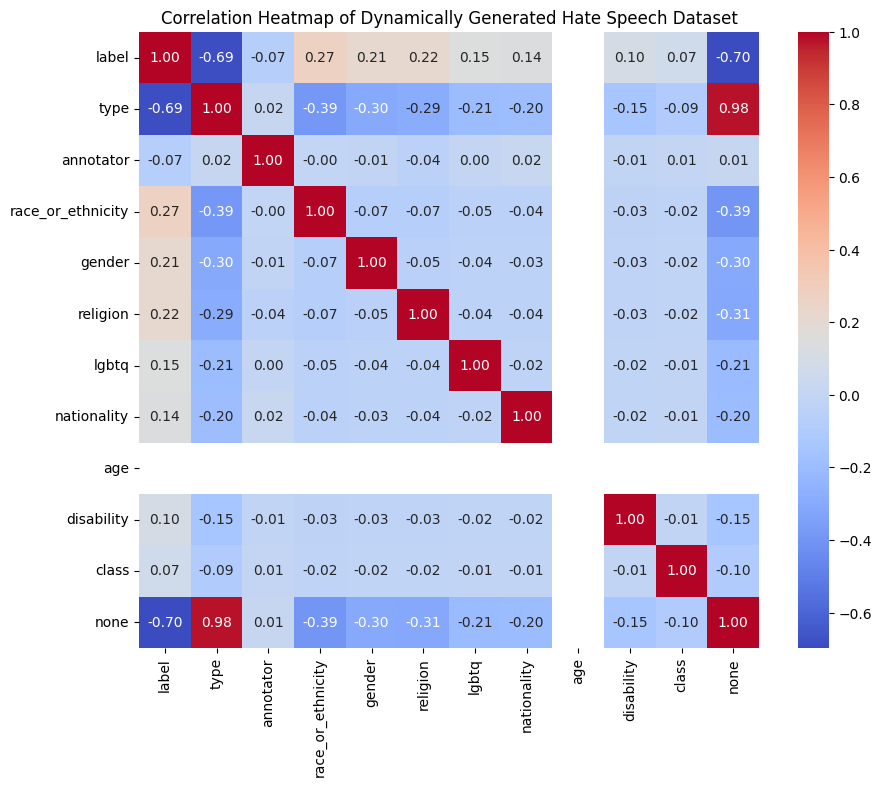

In [36]:
# Create a correlation heatmap of the new columns
plt.figure(figsize=(10, 8))
sns.heatmap(dynamically_generated_hate_speech_dataset_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Dynamically Generated Hate Speech Dataset")
plt.show()

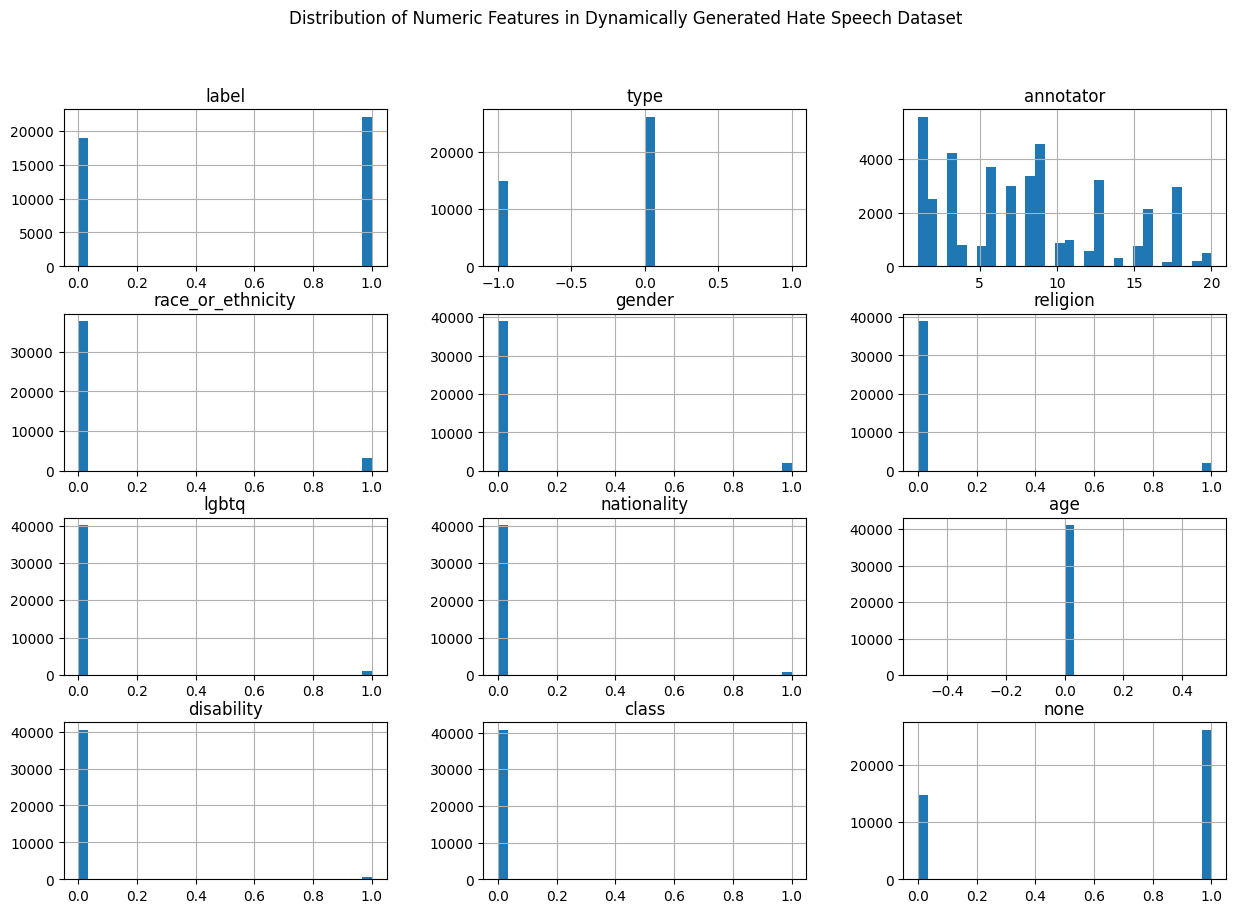

In [37]:
# Plot a histogram of all numeric features in the dynamically_generated_hate_speech_dataset
dynamically_generated_hate_speech_dataset_numeric.hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribution of Numeric Features in Dynamically Generated Hate Speech Dataset")
plt.show()

In [38]:
dynamically_generated_hate_speech_dataset.head()

,label,text,type,level,annotator,race_or_ethnicity,gender,religion,lgbtq,nationality,age,disability,class,none
0,1.0,dalits are lowlives,0,original,3,0,0,0,0,0,0,0,0,1
1,1.0,gay people are a burden to our society,0,original,3,0,0,0,0,0,0,0,0,1
2,1.0,Arabs are not welcome,0,original,18,0,0,0,0,0,0,0,0,1
3,1.0,I'm not saying we should actually eliminate he...,0,original,16,0,0,0,0,0,0,0,0,1
4,1.0,bananas are for black people,0,original,7,0,0,0,0,0,0,0,0,1


In [39]:
# Output the dataframe as a CSV file
dynamically_generated_hate_speech_dataset.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_cleaned1_words.csv", index=False)

# Convabuse

In [44]:
convabuse.head()

,example_no,annotator_id,conv_id,prev_agent,prev_user,agent,user,bot,is_abuse.1,is_abuse.0,...,type.intellectual,type.racist,type.sexist,type.sex_harassment,type.transphobic,target.generalised,target.individual,target.system,direction.explicit,direction.implicit
0,0,7,245846.0,Does that question interest you?,because my finger is happy,Why do you say your finger is happy?,do you rember japan,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,7,159183.0,Does it please you to believe I am a nobe jocky?,bye bye,Please go on.,do you like it hard,E.L.I.Z.A.,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2,7,340147.0,Have you tried?,dick,Please go on.,oh what a pickle dear monastery,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0
3,3,7,95cbaab0f8cb4cb59a3393e7fc61cafe,Will you be travelling in Economy Class?,yes,What city will you be flying from?,Sydney,CarbonBot,1,0,...,0,0,0,0,0,0,0,0,0,0
4,4,7,270732.0,Please go on.,Hello.,How do you do. Please state your problem.,how old are you?,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
# List out the columns of the convabuse dataset
for col in convabuse.columns:
    print(col)

example_no
annotator_id
conv_id
prev_agent
prev_user
agent
user
bot
is_abuse.1
is_abuse.0
is_abuse.-1
is_abuse.-2
is_abuse.-3
type.ableism
type.homophobic
type.intellectual
type.racist
type.sexist
type.sex_harassment
type.transphobic
target.generalised
target.individual
target.system
direction.explicit
direction.implicit


In [46]:
# Remove the terms "type." and "target." from each column name
convabuse.columns = [re.sub(r'^is_abuse\.', '', col) for col in convabuse.columns]
convabuse.columns = [re.sub(r'^type\.', '', col) for col in convabuse.columns]
convabuse.columns = [re.sub(r'^target\.', '', col) for col in convabuse.columns]
convabuse.columns = [re.sub(r'^direction\.', '', col) for col in convabuse.columns]
convabuse.head()

,example_no,annotator_id,conv_id,prev_agent,prev_user,agent,user,bot,1,0,...,intellectual,racist,sexist,sex_harassment,transphobic,generalised,individual,system,explicit,implicit
0,0,7,245846.0,Does that question interest you?,because my finger is happy,Why do you say your finger is happy?,do you rember japan,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,7,159183.0,Does it please you to believe I am a nobe jocky?,bye bye,Please go on.,do you like it hard,E.L.I.Z.A.,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2,7,340147.0,Have you tried?,dick,Please go on.,oh what a pickle dear monastery,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0
3,3,7,95cbaab0f8cb4cb59a3393e7fc61cafe,Will you be travelling in Economy Class?,yes,What city will you be flying from?,Sydney,CarbonBot,1,0,...,0,0,0,0,0,0,0,0,0,0
4,4,7,270732.0,Please go on.,Hello.,How do you do. Please state your problem.,how old are you?,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
# Rename the numeric column names to more understandable names
convabuse = convabuse.rename(columns={
    "1": "Not Abusive",
    "0": "Ambiguous",
    "-1": "Abusive",
    "-2": "Very Abusive",
    "-3": "Very Strongly Abusive"
})

convabuse.head()

,example_no,annotator_id,conv_id,prev_agent,prev_user,agent,user,bot,Not Abusive,Ambiguous,...,intellectual,racist,sexist,sex_harassment,transphobic,generalised,individual,system,explicit,implicit
0,0,7,245846.0,Does that question interest you?,because my finger is happy,Why do you say your finger is happy?,do you rember japan,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,7,159183.0,Does it please you to believe I am a nobe jocky?,bye bye,Please go on.,do you like it hard,E.L.I.Z.A.,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2,7,340147.0,Have you tried?,dick,Please go on.,oh what a pickle dear monastery,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0
3,3,7,95cbaab0f8cb4cb59a3393e7fc61cafe,Will you be travelling in Economy Class?,yes,What city will you be flying from?,Sydney,CarbonBot,1,0,...,0,0,0,0,0,0,0,0,0,0
4,4,7,270732.0,Please go on.,Hello.,How do you do. Please state your problem.,how old are you?,E.L.I.Z.A.,1,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
# Get the numeric features of the convabuse dataset
convabuse_numeric = convabuse.select_dtypes(include=[np.number])
convabuse_numeric.head()

,example_no,annotator_id,Not Abusive,Ambiguous,Abusive,Very Abusive,Very Strongly Abusive,ableism,homophobic,intellectual,racist,sexist,sex_harassment,transphobic,generalised,individual,system,explicit,implicit
0,0,7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,7,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,7,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


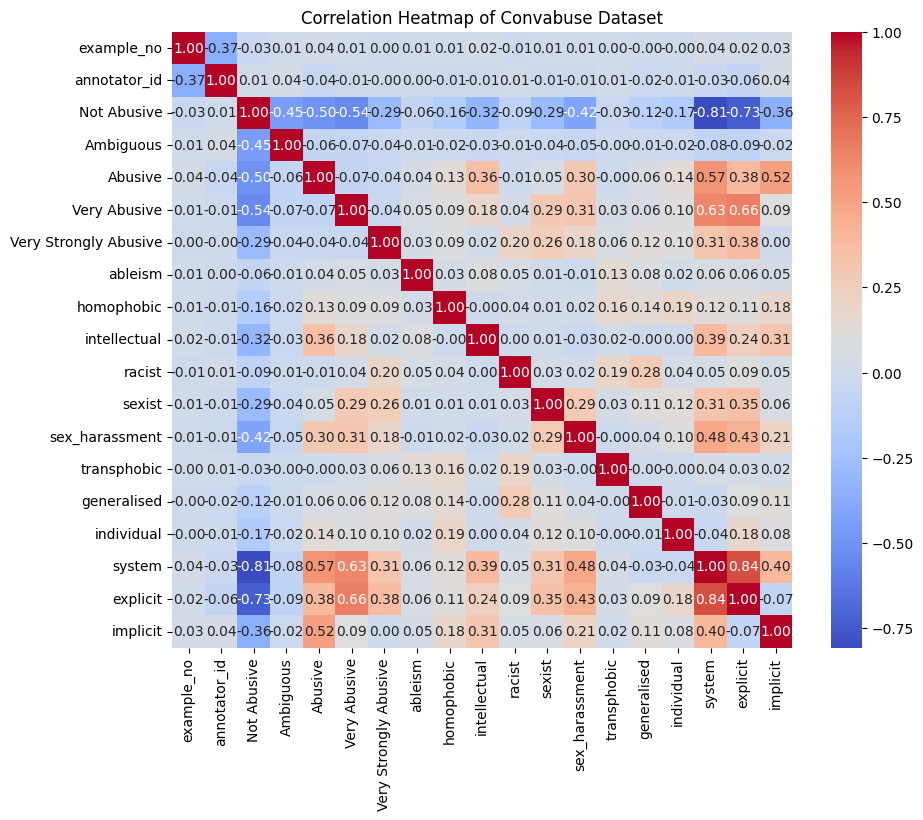

In [49]:
# Create a correlation heatmap of the convabuse dataset
plt.figure(figsize=(10, 8))
sns.heatmap(convabuse_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Convabuse Dataset")
plt.show()

In [50]:
# Output the dataframe as a CSV file
convabuse.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/convabuse_cleaned1_words.csv", index=False)

# Online Abusive Attacks Dataset

In [109]:
online_abusive_attacks.head()

,Num Parent Tweets,Num Replies to Parents,Avg Replies per Parent,Num Parent Tweets with Replies,Avg Replies per Parent with Replies,Num Toxic Parent Tweets,Num Non-Toxic Parent Tweets,Num Toxic Replies,Num Non-Toxic Replies,Num Toxic Replies to Non-Toxic Parents,...,Top Desc Word #1: women,Top Desc Word #2: love,Top Desc Word #3: news,Top Desc Word #4: account,Top Desc Word #5: feminist,Top Desc Word #6: official,Top Desc Word #7: follow,Top Desc Word #8: products,Top Desc Word #9: tweets,Top Desc Word #10: womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,No,No,No,No,No,No,No,No,No,No
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,No,No,No,No,No,No,No,No,No,No
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,No,No,No,No,No,No,No,No,No,No
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,No,No,No,No,No,No,No,No,No,No
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,No,No,No,No,No,No,No,No,No,No


In [110]:
# Remove the term "Top Desc Word " from the column names
online_abusive_attacks.columns = [re.sub(r'^Top Desc Word ', '', col) for col in online_abusive_attacks.columns]
online_abusive_attacks.head()

,Num Parent Tweets,Num Replies to Parents,Avg Replies per Parent,Num Parent Tweets with Replies,Avg Replies per Parent with Replies,Num Toxic Parent Tweets,Num Non-Toxic Parent Tweets,Num Toxic Replies,Num Non-Toxic Replies,Num Toxic Replies to Non-Toxic Parents,...,#1: women,#2: love,#3: news,#4: account,#5: feminist,#6: official,#7: follow,#8: products,#9: tweets,#10: womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,No,No,No,No,No,No,No,No,No,No
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,No,No,No,No,No,No,No,No,No,No
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,No,No,No,No,No,No,No,No,No,No
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,No,No,No,No,No,No,No,No,No,No
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,No,No,No,No,No,No,No,No,No,No


In [111]:
# For each of the final 10 columns, use a for loop to remove any leading "#i: " values from the column names
for i in range(1, 11):
    online_abusive_attacks.columns = [re.sub(rf'^#{i}: ', '', col) for col in online_abusive_attacks.columns]

online_abusive_attacks.head()

,Num Parent Tweets,Num Replies to Parents,Avg Replies per Parent,Num Parent Tweets with Replies,Avg Replies per Parent with Replies,Num Toxic Parent Tweets,Num Non-Toxic Parent Tweets,Num Toxic Replies,Num Non-Toxic Replies,Num Toxic Replies to Non-Toxic Parents,...,women,love,news,account,feminist,official,follow,products,tweets,womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,No,No,No,No,No,No,No,No,No,No
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,No,No,No,No,No,No,No,No,No,No
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,No,No,No,No,No,No,No,No,No,No
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,No,No,No,No,No,No,No,No,No,No
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,No,No,No,No,No,No,No,No,No,No


In [112]:
# Remove the phrase "Num " from the column names
online_abusive_attacks.columns = [re.sub(r'^Num ', '', col) for col in online_abusive_attacks.columns]
online_abusive_attacks.head()

,Parent Tweets,Replies to Parents,Avg Replies per Parent,Parent Tweets with Replies,Avg Replies per Parent with Replies,Toxic Parent Tweets,Non-Toxic Parent Tweets,Toxic Replies,Non-Toxic Replies,Toxic Replies to Non-Toxic Parents,...,women,love,news,account,feminist,official,follow,products,tweets,womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,No,No,No,No,No,No,No,No,No,No
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,No,No,No,No,No,No,No,No,No,No
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,No,No,No,No,No,No,No,No,No,No
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,No,No,No,No,No,No,No,No,No,No
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,No,No,No,No,No,No,No,No,No,No


In [113]:
# Capitalize all column names
online_abusive_attacks.columns = [col.capitalize() for col in online_abusive_attacks.columns]
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Women,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,No,No,No,No,No,No,No,No,No,No
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,No,No,No,No,No,No,No,No,No,No
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,No,No,No,No,No,No,No,No,No,No
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,No,No,No,No,No,No,No,No,No,No
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,No,No,No,No,No,No,No,No,No,No


In [114]:
# Get info from each column
for col in online_abusive_attacks.columns:
    print(f"{col}: {online_abusive_attacks[col].dtype}")

Parent tweets: float64
Replies to parents: float64
Avg replies per parent: float64
Parent tweets with replies: float64
Avg replies per parent with replies: float64
Toxic parent tweets: float64
Non-toxic parent tweets: float64
Toxic replies: float64
Non-toxic replies: float64
Toxic replies to non-toxic parents: float64
Non-toxic replies to non-toxic parents: float64
Toxic replies to toxic parents: float64
Non-toxic replies to toxic parents: float64
Followers_count: float64
Friends_count: float64
Listed_count: float64
Created_at: object
Favourites_count: float64
Geo_enabled: object
Verified: object
Statuses_count: float64
Contributors_enabled: object
Is_translator: object
Is_translation_enabled: object
Has_extended_profile: object
Default_profile: object
Default_profile_image: object
Following: object
Follow_request_sent: object
Notifications: object
Geo: object
Place: object
Truncated: object
Hashtags: object
Symbols: object
User_mentions: object
Urls: object
Contributors: object
Is_quo

In [115]:
# Get all object type columns except for the last 10 columns
online_abusive_attacks_object = online_abusive_attacks.select_dtypes(include=[object]).iloc[:, :-10]
online_abusive_attacks_object.head()

,Created_at,Geo_enabled,Verified,Contributors_enabled,Is_translator,Is_translation_enabled,Has_extended_profile,Default_profile,Default_profile_image,Following,...,Hashtags,Symbols,User_mentions,Urls,Contributors,Is_quote_status,Favorited,Retweeted,Possibly_sensitive,User desc
0,Sun Dec 09 21:20:59 +0000 2012,Yes,No,No,No,No,Yes,Yes,No,No,...,Yes,No,Yes,Yes,No,Yes,No,No,Yes,User Desc
1,Sat May 26 21:15:24 +0000 2018,No,No,No,No,No,Yes,Yes,No,No,...,Yes,Yes,Yes,Yes,No,Yes,No,No,No,User Desc
2,Sat May 26 21:15:24 +0000 2018,No,No,No,No,No,Yes,Yes,No,No,...,Yes,No,Yes,Yes,No,Yes,No,No,No,User Desc
3,Sat May 26 21:15:24 +0000 2018,No,No,No,No,No,Yes,Yes,No,No,...,Yes,Yes,Yes,Yes,No,Yes,No,No,No,User Desc
4,Sat May 26 21:15:24 +0000 2018,No,No,No,No,No,Yes,Yes,No,No,...,Yes,Yes,Yes,Yes,No,Yes,No,No,No,User Desc


In [116]:
# Head of the 11th to 20th object type columns
online_abusive_attacks_object.iloc[:, 10:21].head()

,Follow_request_sent,Notifications,Geo,Place,Truncated,Hashtags,Symbols,User_mentions,Urls,Contributors,Is_quote_status
0,No,No,No,No,No,Yes,No,Yes,Yes,No,Yes
1,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes
2,No,No,No,No,No,Yes,No,Yes,Yes,No,Yes
3,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes
4,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes


In [117]:
# Head of the 21st to last object type columns
online_abusive_attacks_object.iloc[:, 21:].head()

,Favorited,Retweeted,Possibly_sensitive,User desc
0,No,No,Yes,User Desc
1,No,No,No,User Desc
2,No,No,No,User Desc
3,No,No,No,User Desc
4,No,No,No,User Desc


In [118]:
# Drop "Verified" and "Possible_sensitive" from the object columns
online_abusive_attacks_object = online_abusive_attacks_object.drop(columns=['Verified', 'Possibly_sensitive'])
online_abusive_attacks_object.head()

,Created_at,Geo_enabled,Contributors_enabled,Is_translator,Is_translation_enabled,Has_extended_profile,Default_profile,Default_profile_image,Following,Follow_request_sent,...,Truncated,Hashtags,Symbols,User_mentions,Urls,Contributors,Is_quote_status,Favorited,Retweeted,User desc
0,Sun Dec 09 21:20:59 +0000 2012,Yes,No,No,No,Yes,Yes,No,No,No,...,No,Yes,No,Yes,Yes,No,Yes,No,No,User Desc
1,Sat May 26 21:15:24 +0000 2018,No,No,No,No,Yes,Yes,No,No,No,...,No,Yes,Yes,Yes,Yes,No,Yes,No,No,User Desc
2,Sat May 26 21:15:24 +0000 2018,No,No,No,No,Yes,Yes,No,No,No,...,No,Yes,No,Yes,Yes,No,Yes,No,No,User Desc
3,Sat May 26 21:15:24 +0000 2018,No,No,No,No,Yes,Yes,No,No,No,...,No,Yes,Yes,Yes,Yes,No,Yes,No,No,User Desc
4,Sat May 26 21:15:24 +0000 2018,No,No,No,No,Yes,Yes,No,No,No,...,No,Yes,Yes,Yes,Yes,No,Yes,No,No,User Desc


In [119]:
# Remove the object type columns
online_abusive_attacks = online_abusive_attacks.drop(columns=online_abusive_attacks_object.columns).reset_index(drop=True)
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Women,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,No,No,No,No,No,No,No,No,No,No
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,No,No,No,No,No,No,No,No,No,No
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,No,No,No,No,No,No,No,No,No,No
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,No,No,No,No,No,No,No,No,No,No
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,No,No,No,No,No,No,No,No,No,No


In [120]:
# Check for NaN values for each column in the online_abusive_attacks dataset
for col in online_abusive_attacks.columns:
    print(f"{col}: {online_abusive_attacks[col].isna().sum()} NaN values")

Parent tweets: 0 NaN values
Replies to parents: 0 NaN values
Avg replies per parent: 0 NaN values
Parent tweets with replies: 0 NaN values
Avg replies per parent with replies: 0 NaN values
Toxic parent tweets: 0 NaN values
Non-toxic parent tweets: 0 NaN values
Toxic replies: 0 NaN values
Non-toxic replies: 0 NaN values
Toxic replies to non-toxic parents: 0 NaN values
Non-toxic replies to non-toxic parents: 0 NaN values
Toxic replies to toxic parents: 0 NaN values
Non-toxic replies to toxic parents: 0 NaN values
Followers_count: 0 NaN values
Friends_count: 0 NaN values
Listed_count: 0 NaN values
Favourites_count: 0 NaN values
Verified: 0 NaN values
Statuses_count: 0 NaN values
Retweet_count min: 0 NaN values
Retweet_count avg: 0 NaN values
Retweet_count max: 0 NaN values
Favorite_count min: 0 NaN values
Favorite_count avg: 0 NaN values
Favorite_count max: 0 NaN values
Possibly_sensitive: 0 NaN values
Repliers with min 1 toxic reply: 0 NaN values
Parents with high toxicity: 0 NaN values


In [121]:
# Encode the final ten columns as binary integer values
for col in online_abusive_attacks.columns[-10:]:
    # If the value of for each entry in the column is "No", change it to 0, otherwise change it to 1
    online_abusive_attacks[col] = online_abusive_attacks[col].apply(lambda x: 0 if x == "No" else 1)

online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Women,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,0


In [122]:
# Encode the verified column as binary integer values where "No" is 0 and "Yes" is 1
online_abusive_attacks["Verified"] = online_abusive_attacks["Verified"].apply(lambda x: 0 if x == "No" else 1)
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Women,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,0


In [123]:
# Encode the Possibly_sensitive column as binary integer values where "No" is 0 and "Yes" is 1
online_abusive_attacks["Possibly_sensitive"] = online_abusive_attacks["Possibly_sensitive"].apply(lambda x: 0 if x == "No" else 1)
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Women,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,0


In [124]:
# Get the numeric features of the online_abusive_attacks dataset
online_abusive_attacks_numeric = online_abusive_attacks.select_dtypes(include=[np.number])
online_abusive_attacks_numeric.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Women,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,0


In [125]:
for col in online_abusive_attacks.columns:
    print(col)

Parent tweets
Replies to parents
Avg replies per parent
Parent tweets with replies
Avg replies per parent with replies
Toxic parent tweets
Non-toxic parent tweets
Toxic replies
Non-toxic replies
Toxic replies to non-toxic parents
Non-toxic replies to non-toxic parents
Toxic replies to toxic parents
Non-toxic replies to toxic parents
Followers_count
Friends_count
Listed_count
Favourites_count
Verified
Statuses_count
Retweet_count min
Retweet_count avg
Retweet_count max
Favorite_count min
Favorite_count avg
Favorite_count max
Possibly_sensitive
Repliers with min 1 toxic reply
Parents with high toxicity
Parents with high severe_toxicity
Parents with high identity_attack
Parents with high insult
Parents with high profanity
Parents with high threat
Parents with high other attr
Replies with high toxicity
Replies with high severe_toxicity
Replies with high identity_attack
Replies with high insult
Replies with high profanity
Replies with high threat
Replies with high other attr
Total tweets wi

In [126]:
# Take the sum of high Toxicity, high Severe_Toxicity, high Identity_Attack, high Insult, high Profanity, high Threat, and high other attr to calculate a new column "Toxicity"
online_abusive_attacks["Toxicity"] = online_abusive_attacks["Total tweets with high toxicity"] + online_abusive_attacks["Total tweets with high severe_toxicity"] + online_abusive_attacks["Total tweets with high identity_attack"] + online_abusive_attacks["Total tweets with high insult"] + online_abusive_attacks["Total tweets with high profanity"] + online_abusive_attacks["Total tweets with high threat"] + online_abusive_attacks["Total tweets with high other attr"]

# Drop the aforementioned columns now that Toxicity has been calculated
online_abusive_attacks = online_abusive_attacks.drop(columns=["Total tweets with high toxicity", "Total tweets with high severe_toxicity", "Total tweets with high identity_attack", "Total tweets with high insult", "Total tweets with high profanity", "Total tweets with high threat", "Total tweets with high other attr"])
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,80.0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,73.0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,96.0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,104.0


In [129]:
# Replace "Parents with " with "" in the relevant column names
online_abusive_attacks.columns = [(col.replace("Parents with ", "") + " Parents").upper() if "Parents with" in col else col for col in online_abusive_attacks.columns]
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,80.0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,73.0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,96.0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,104.0


In [130]:
# Replace "Replies with " with "" in the relevant column names
online_abusive_attacks.columns = [(col.replace("Replies with ", "") + " Replies").upper() if "Replies with" in col else col for col in online_abusive_attacks.columns]
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,80.0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,73.0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,96.0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,104.0


In [131]:
for col in online_abusive_attacks.columns:
    print(col)

Parent tweets
Replies to parents
Avg replies per parent
Parent tweets with replies
Avg replies per parent with replies
Toxic parent tweets
Non-toxic parent tweets
Toxic replies
Non-toxic replies
Toxic replies to non-toxic parents
Non-toxic replies to non-toxic parents
Toxic replies to toxic parents
Non-toxic replies to toxic parents
Followers_count
Friends_count
Listed_count
Favourites_count
Verified
Statuses_count
Retweet_count min
Retweet_count avg
Retweet_count max
Favorite_count min
Favorite_count avg
Favorite_count max
Possibly_sensitive
Repliers with min 1 toxic reply
HIGH TOXICITY PARENTS
HIGH SEVERE_TOXICITY PARENTS
HIGH IDENTITY_ATTACK PARENTS
HIGH INSULT PARENTS
HIGH PROFANITY PARENTS
HIGH THREAT PARENTS
HIGH OTHER ATTR PARENTS
HIGH TOXICITY REPLIES
HIGH SEVERE_TOXICITY REPLIES
HIGH IDENTITY_ATTACK REPLIES
HIGH INSULT REPLIES
HIGH PROFANITY REPLIES
HIGH THREAT REPLIES
HIGH OTHER ATTR REPLIES
Repliers
<3 REPLIES PARENTS
>=3 REPLIES PARENTS
Women
Love
News
Account
Feminist
Offi

In [132]:
# Apply lowercase, then capitalize each column name
online_abusive_attacks.columns = [col.lower().capitalize() for col in online_abusive_attacks.columns]
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,80.0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,73.0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,96.0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,104.0


In [134]:
for col in online_abusive_attacks.columns:
    print(col)

Parent tweets
Replies to parents
Avg replies per parent
Parent tweets with replies
Avg replies per parent with replies
Toxic parent tweets
Non-toxic parent tweets
Toxic replies
Non-toxic replies
Toxic replies to non-toxic parents
Non-toxic replies to non-toxic parents
Toxic replies to toxic parents
Non-toxic replies to toxic parents
Followers_count
Friends_count
Listed_count
Favourites_count
Verified
Statuses_count
Retweet_count min
Retweet_count avg
Retweet_count max
Favorite_count min
Favorite_count avg
Favorite_count max
Possibly_sensitive
Repliers with min 1 toxic reply
High toxicity parents
High severe_toxicity parents
High identity_attack parents
High insult parents
High profanity parents
High threat parents
High other attr parents
High toxicity replies
High severe_toxicity replies
High identity_attack replies
High insult replies
High profanity replies
High threat replies
High other attr replies
Repliers
<3 replies parents
>=3 replies parents
Women
Love
News
Account
Feminist
Offi

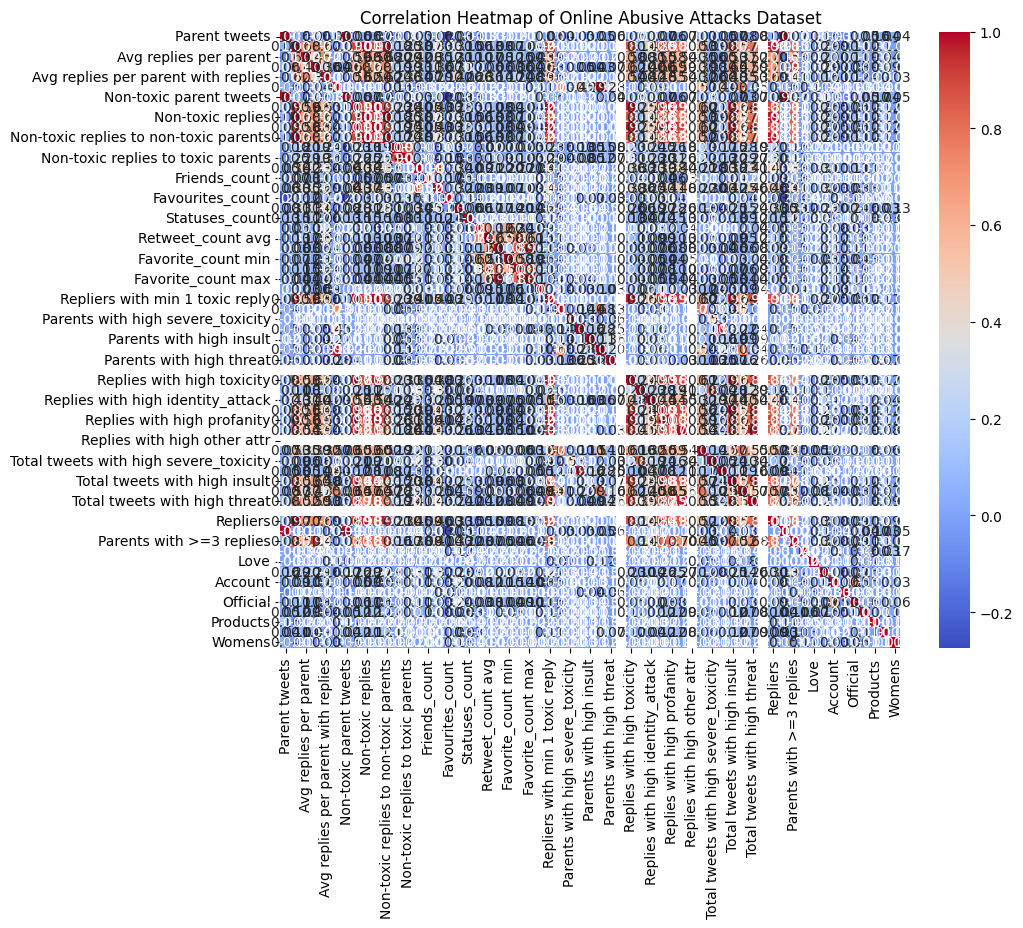

In [135]:
# Create a correlation heatmap of the online_abusive_attacks dataset
plt.figure(figsize=(10, 8))
sns.heatmap(online_abusive_attacks_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Online Abusive Attacks Dataset")
plt.show()

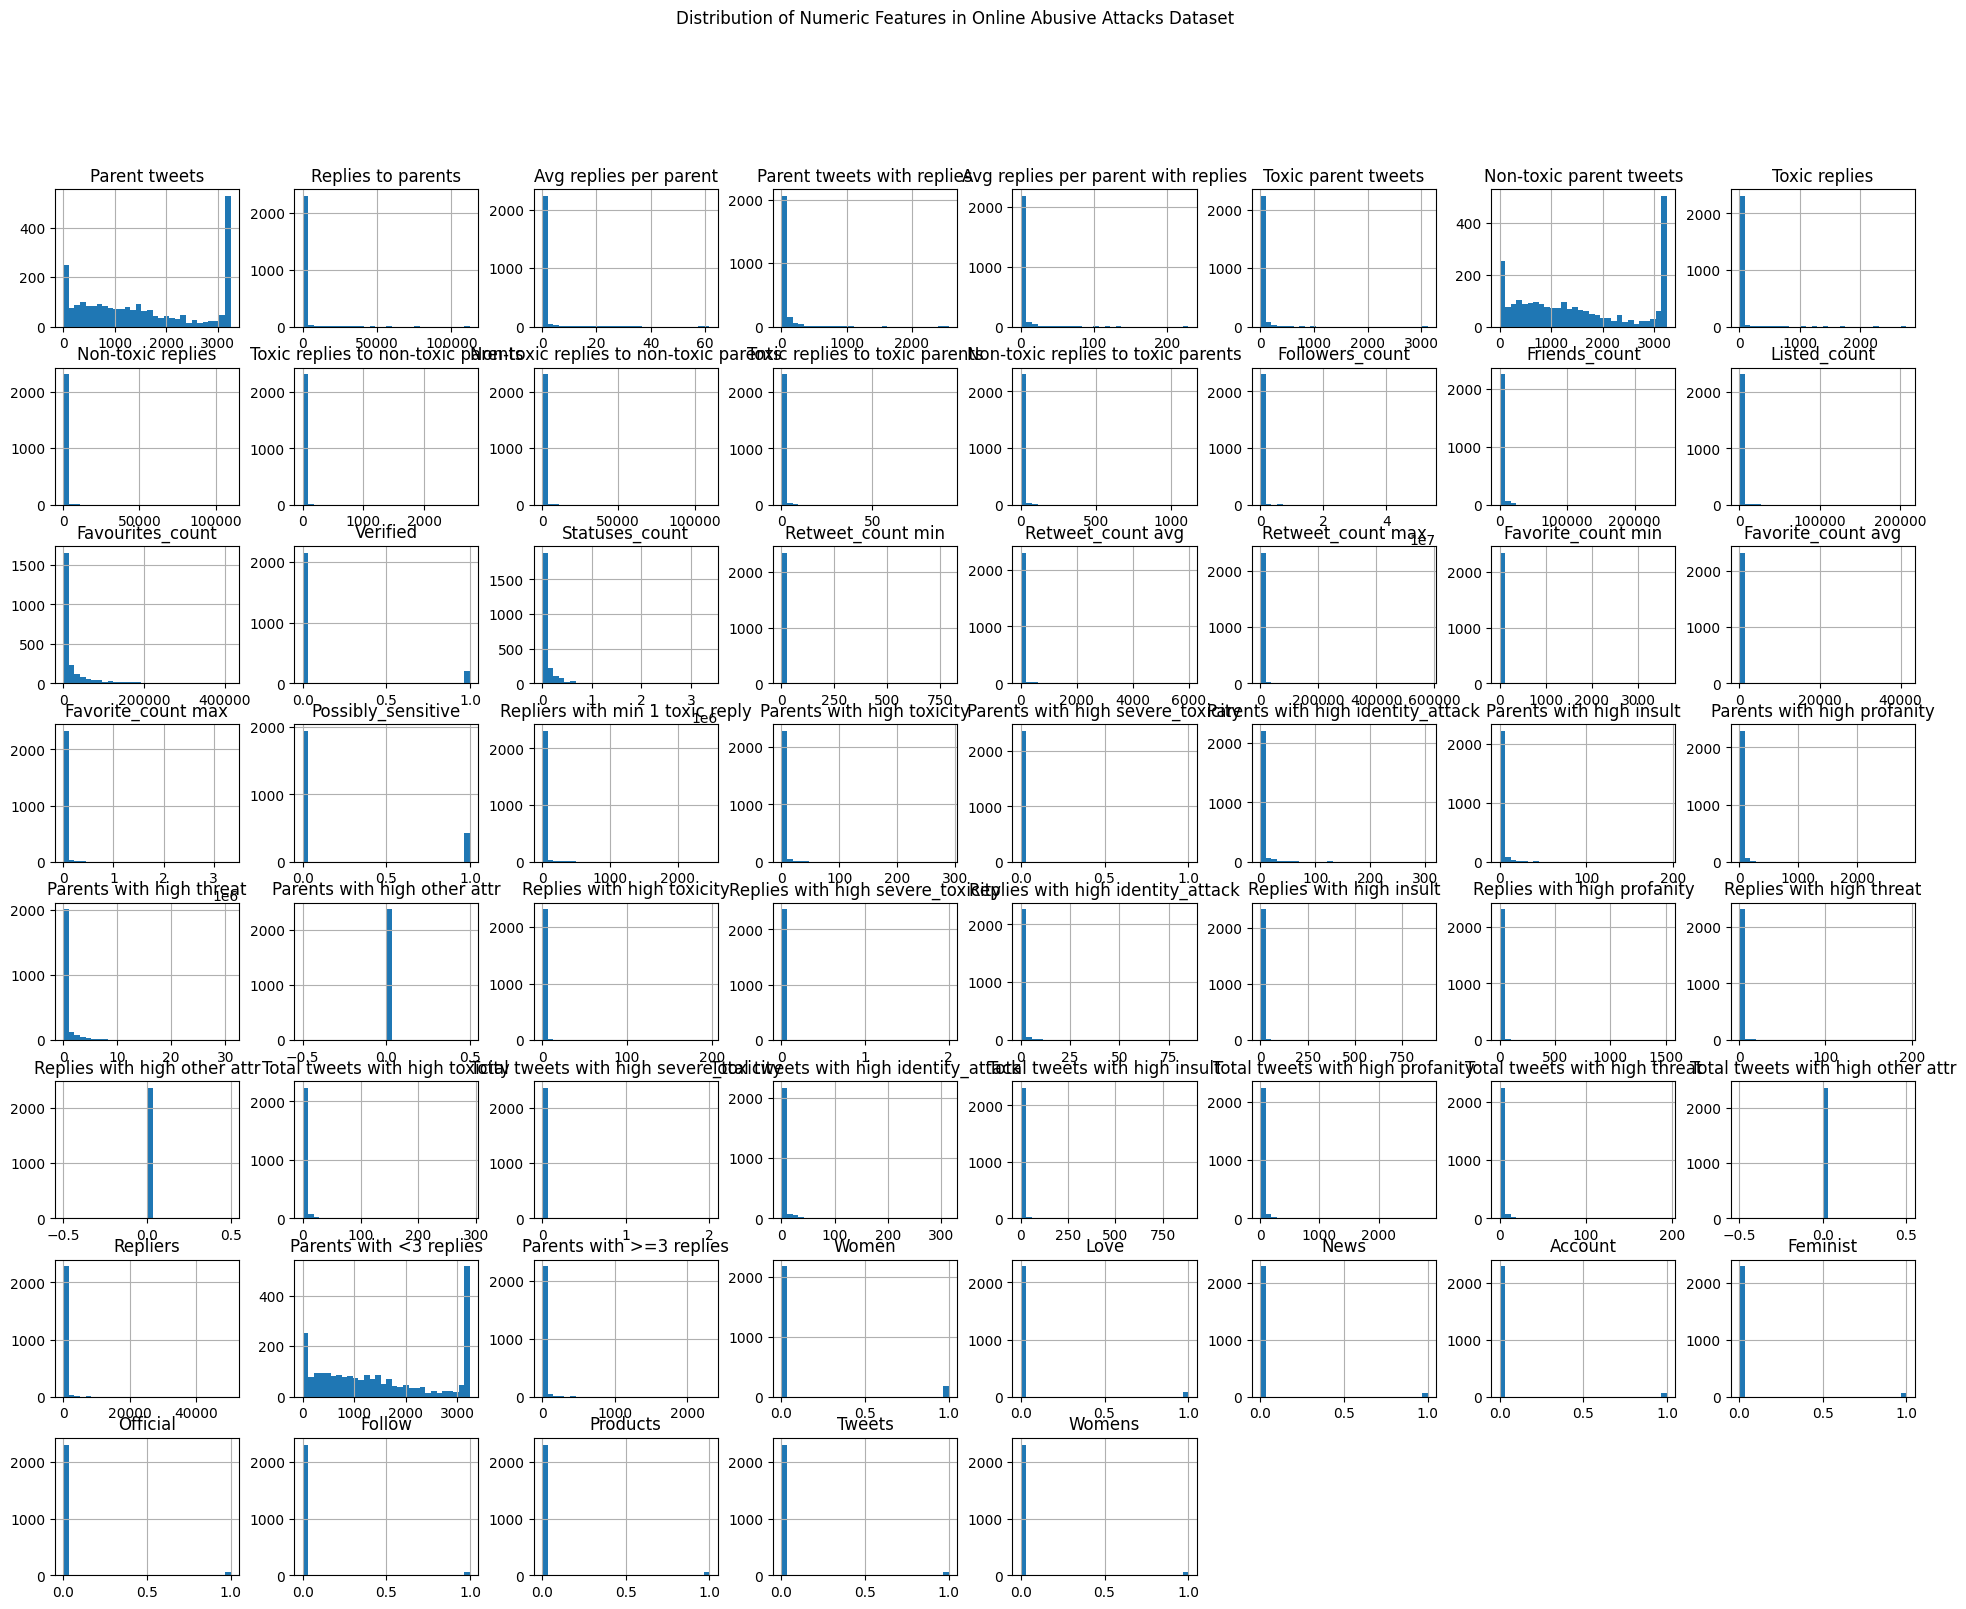

In [137]:
# Generate a histogram of all numeric features in the online_abusive_attacks dataset
online_abusive_attacks_numeric.hist(bins=30, figsize=(24, 18))
plt.suptitle("Distribution of Numeric Features in Online Abusive Attacks Dataset")
plt.show()

In [138]:
# Get the numeric features of the X_columns and y_columns
online_abusive_attacks_X = online_abusive_attacks.drop("Toxicity", axis=1)
online_abusive_attacks_y = online_abusive_attacks["Toxicity"]

In [139]:
online_abusive_attacks_X.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Women,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,0


In [140]:
online_abusive_attacks_y.head()

,Toxicity
0,0.0
1,80.0
2,73.0
3,96.0
4,104.0


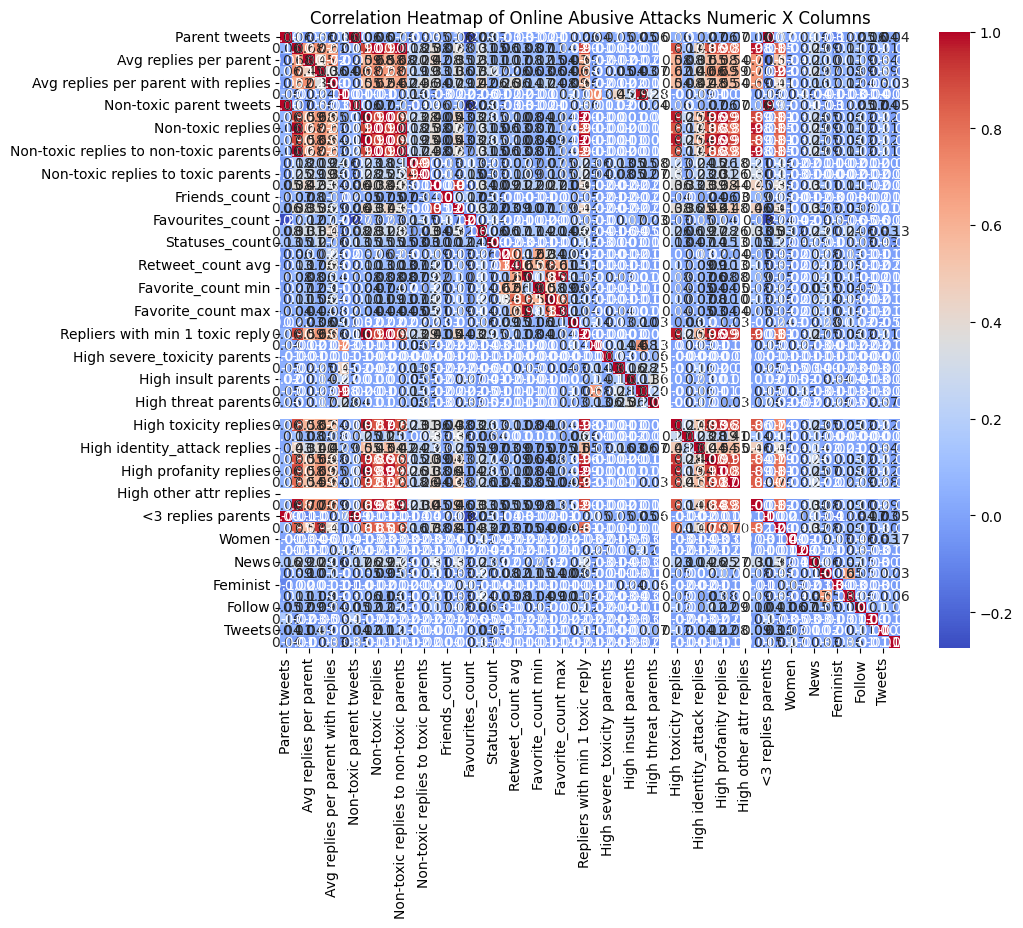

In [141]:
# Get a correlation heatmap of the numeric X_columns only
plt.figure(figsize=(10, 8))
sns.heatmap(online_abusive_attacks_X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Online Abusive Attacks Numeric X Columns")
plt.show()


In [142]:
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,80.0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,73.0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,96.0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,104.0


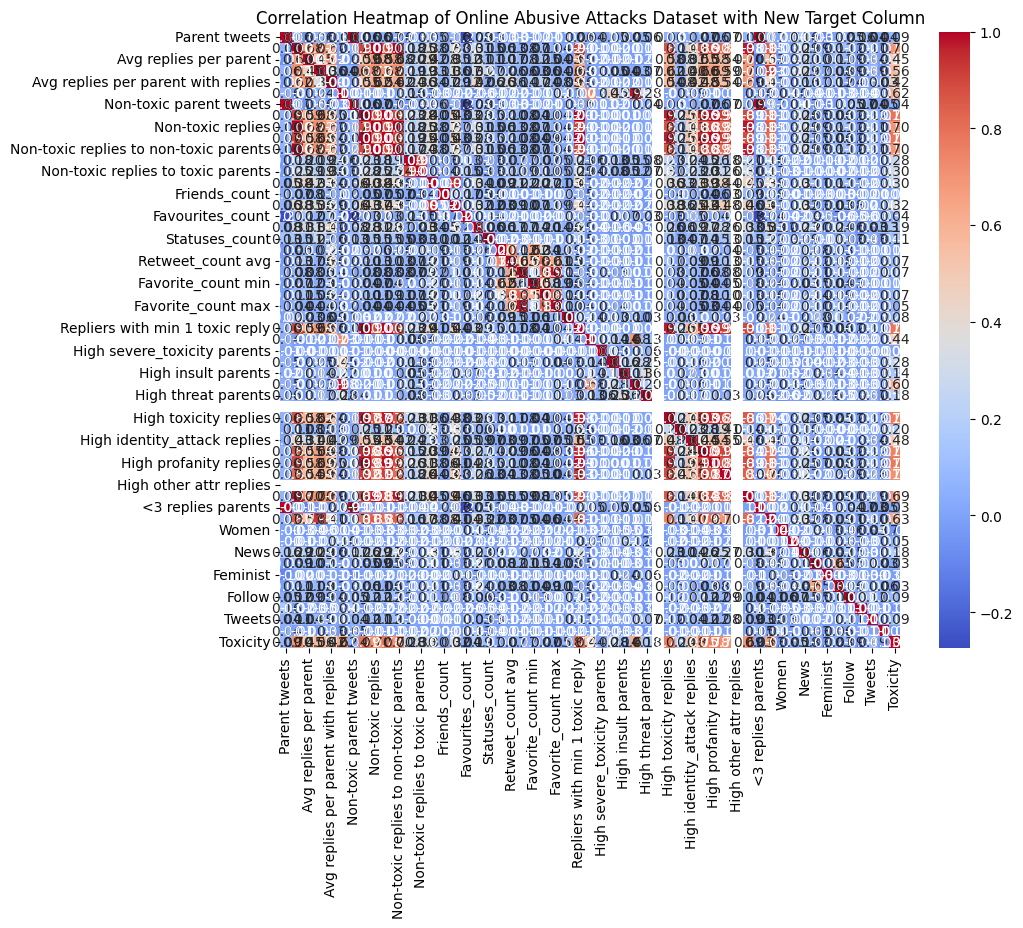

In [143]:
# Create a correlation heatmap of the new dataset
plt.figure(figsize=(10, 8))
sns.heatmap(online_abusive_attacks.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Online Abusive Attacks Dataset with New Target Column")
plt.show()

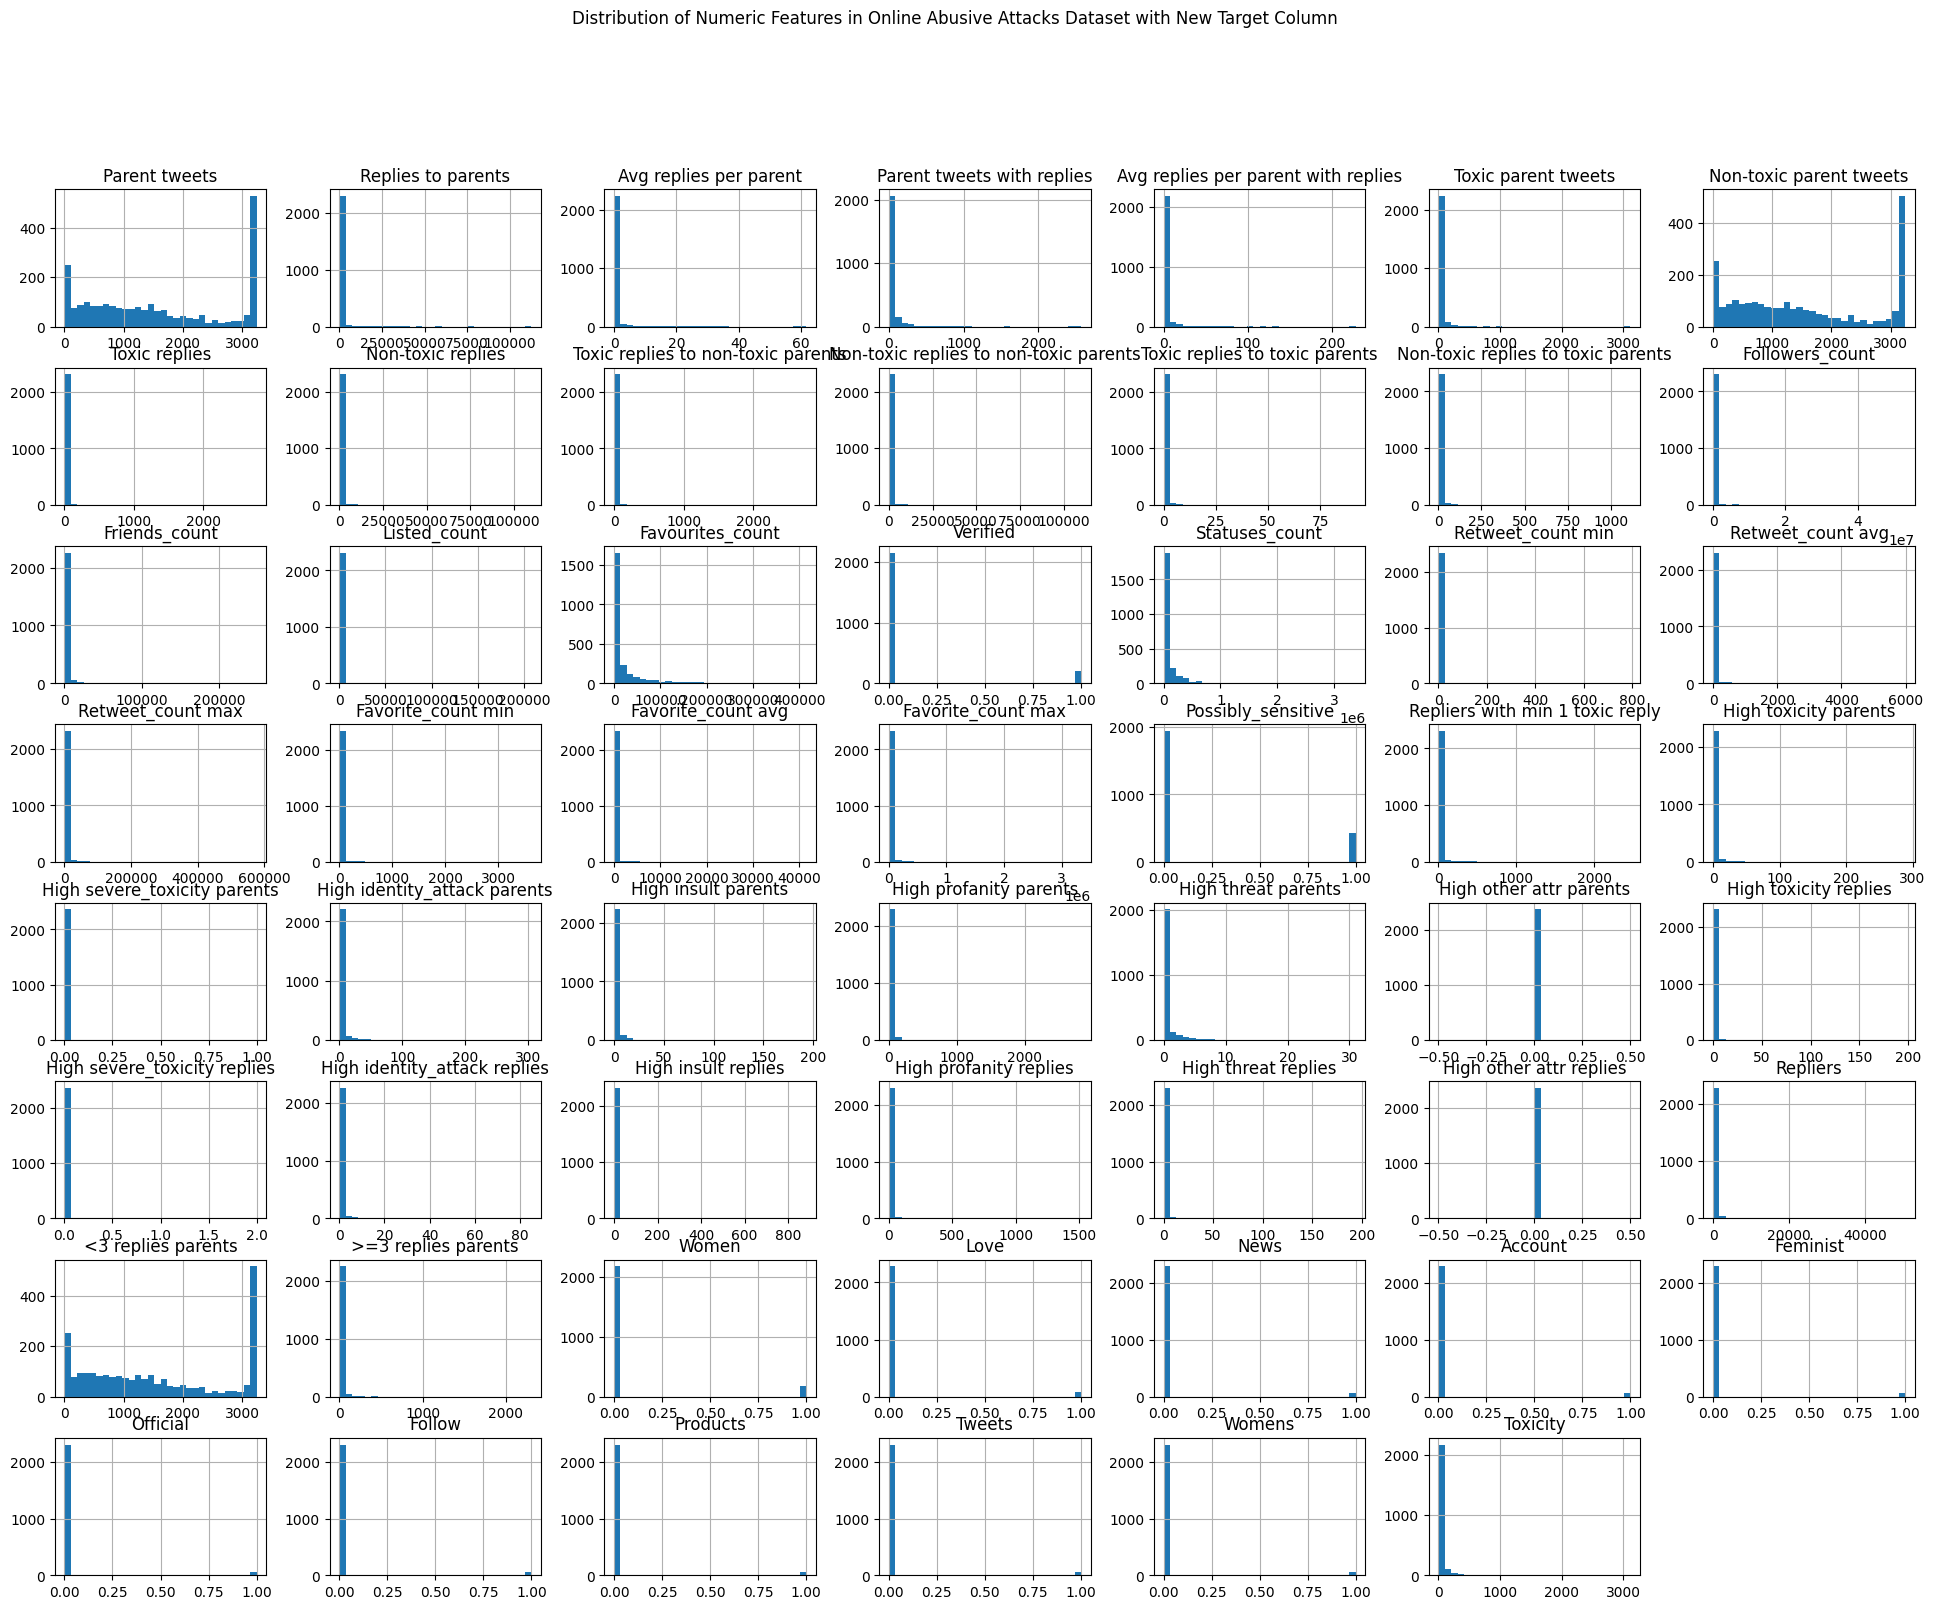

In [144]:
# Create a histogram of all numeric features in the new dataset
online_abusive_attacks.hist(bins=30, figsize=(24, 18))
plt.suptitle("Distribution of Numeric Features in Online Abusive Attacks Dataset with New Target Column")
plt.show()

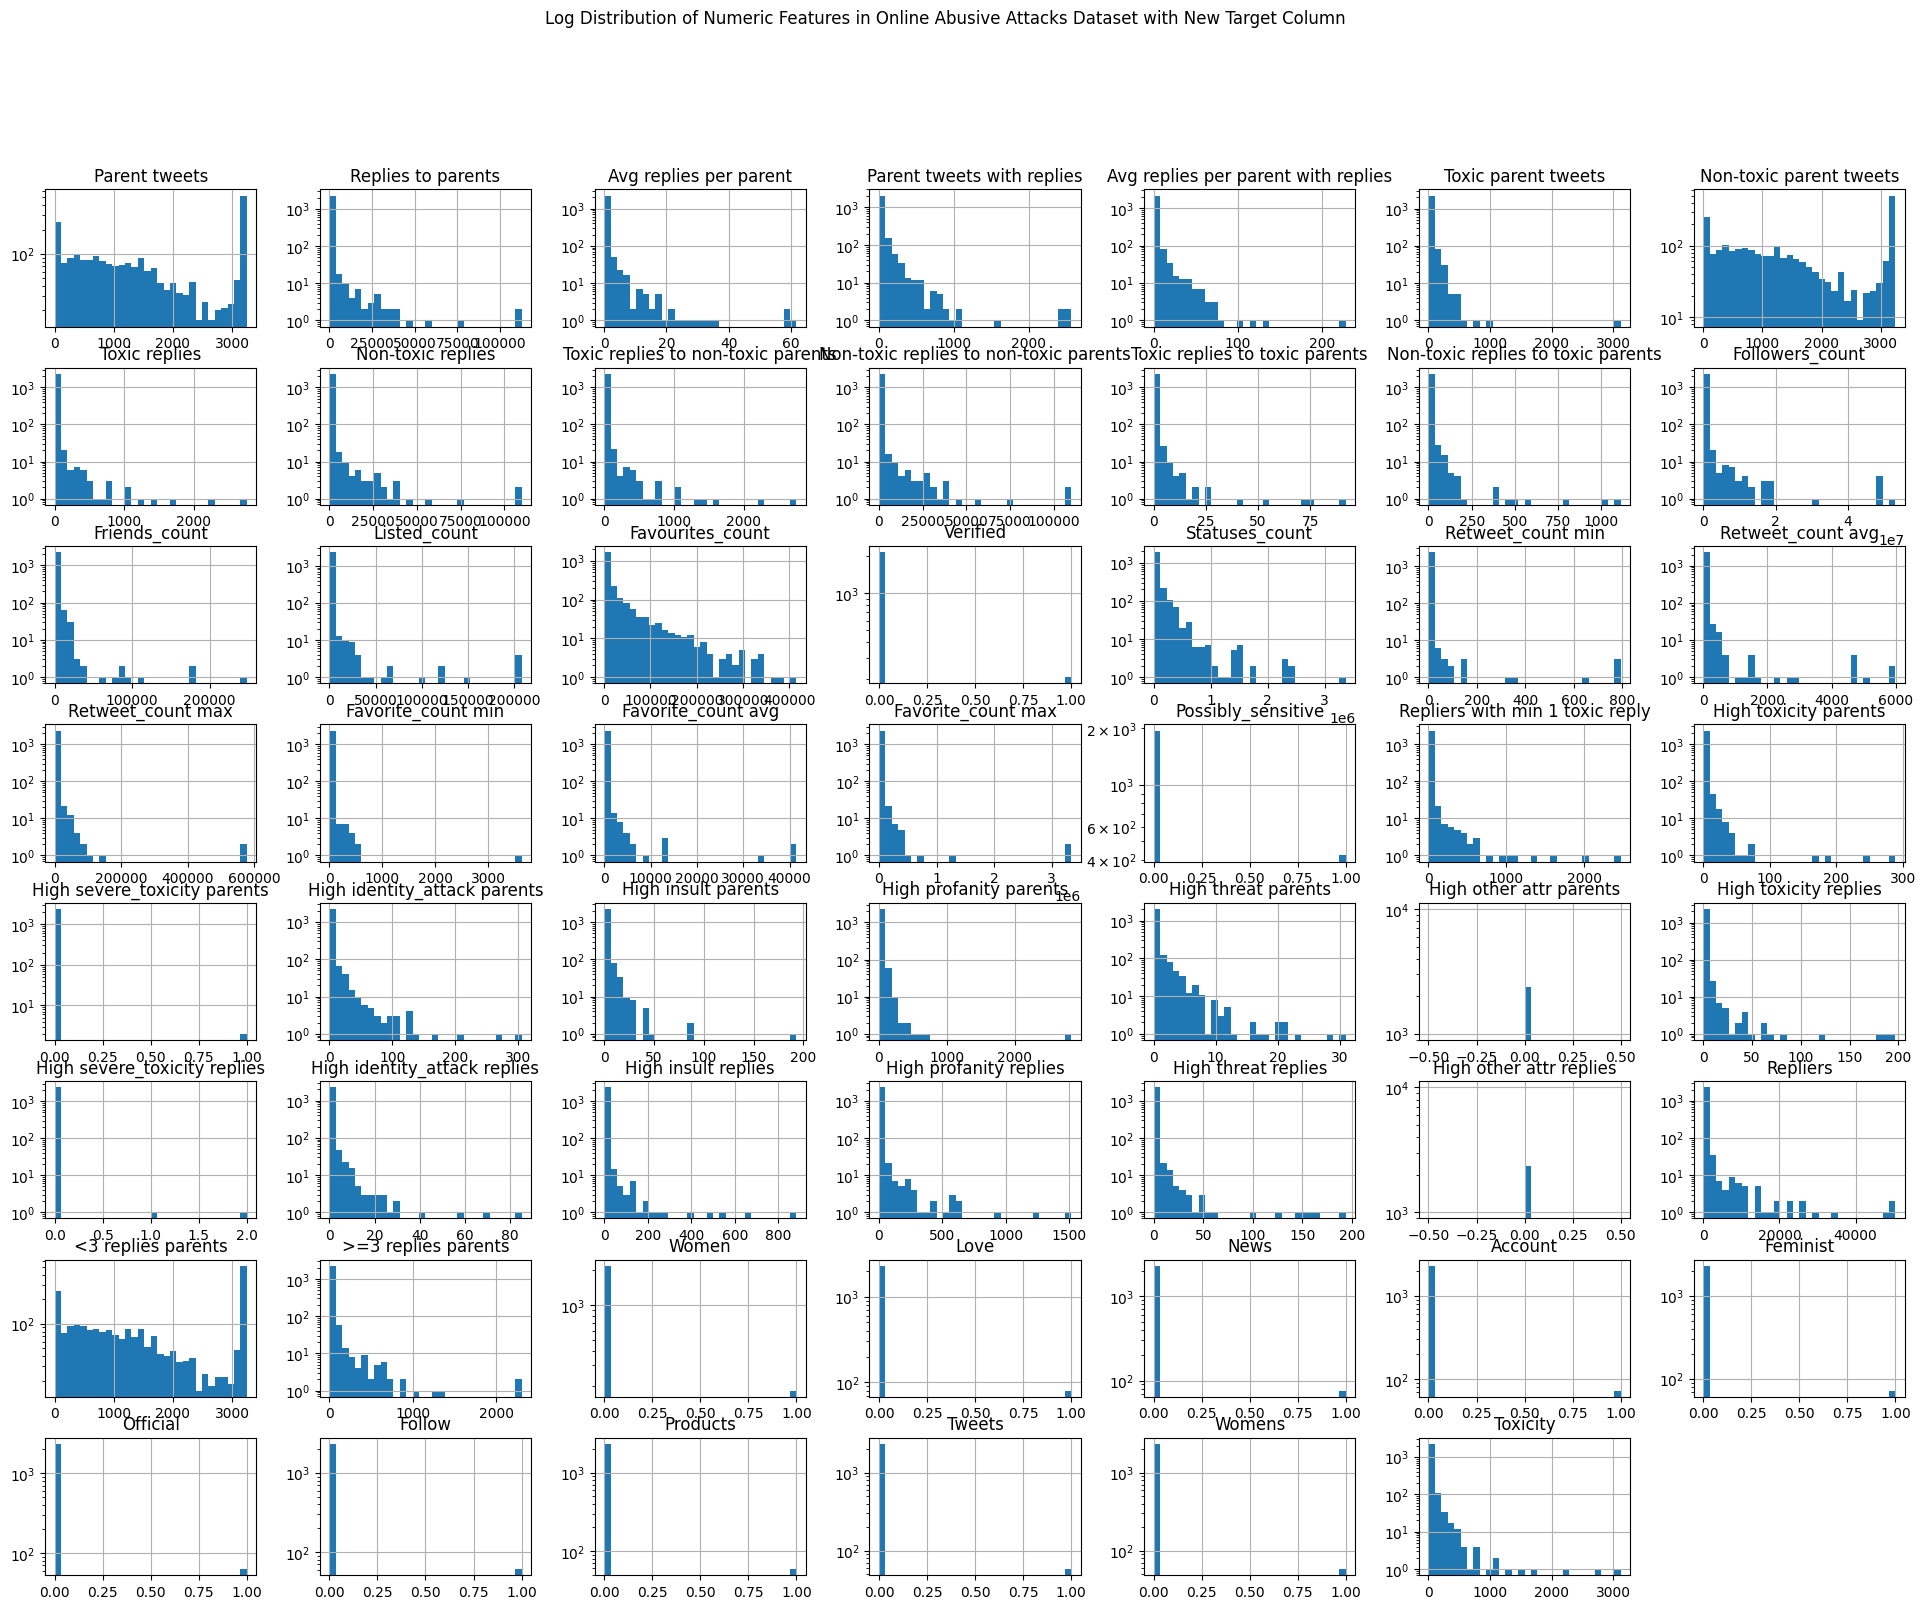

In [145]:
# Plot a log histogram of all numeric features in the balanced dataset
online_abusive_attacks.hist(bins=30, figsize=(24, 18), log=True)
plt.suptitle("Log Distribution of Numeric Features in Online Abusive Attacks Dataset with New Target Column")
plt.show()

In [146]:
# Output the dataframe as a CSV file
online_abusive_attacks.to_csv("/content/drive/MyDrive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_cleaned1.csv", index=False)